In [1]:
import cv2
import numpy as np
import easyocr

reader = easyocr.Reader(['en'], gpu=True)

def eliminar_texto(image_path, umbral_confianza=0.3):
    img = cv2.imread(image_path)
    resultado = reader.readtext(image_path, detail=1)
    
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    
    for (bbox, texto, confianza) in resultado:
        if confianza > umbral_confianza:
            pts = np.array(bbox, dtype=np.int32)
            # Pequeño margen para cubrir bordes del texto
            cv2.fillPoly(mask, [pts], 255)
    
    # TELEA es mejor para texturas continuas como tejido pulmonar
    img_limpia = cv2.inpaint(img, mask, inpaintRadius=7, flags=cv2.INPAINT_TELEA)
    return img_limpia


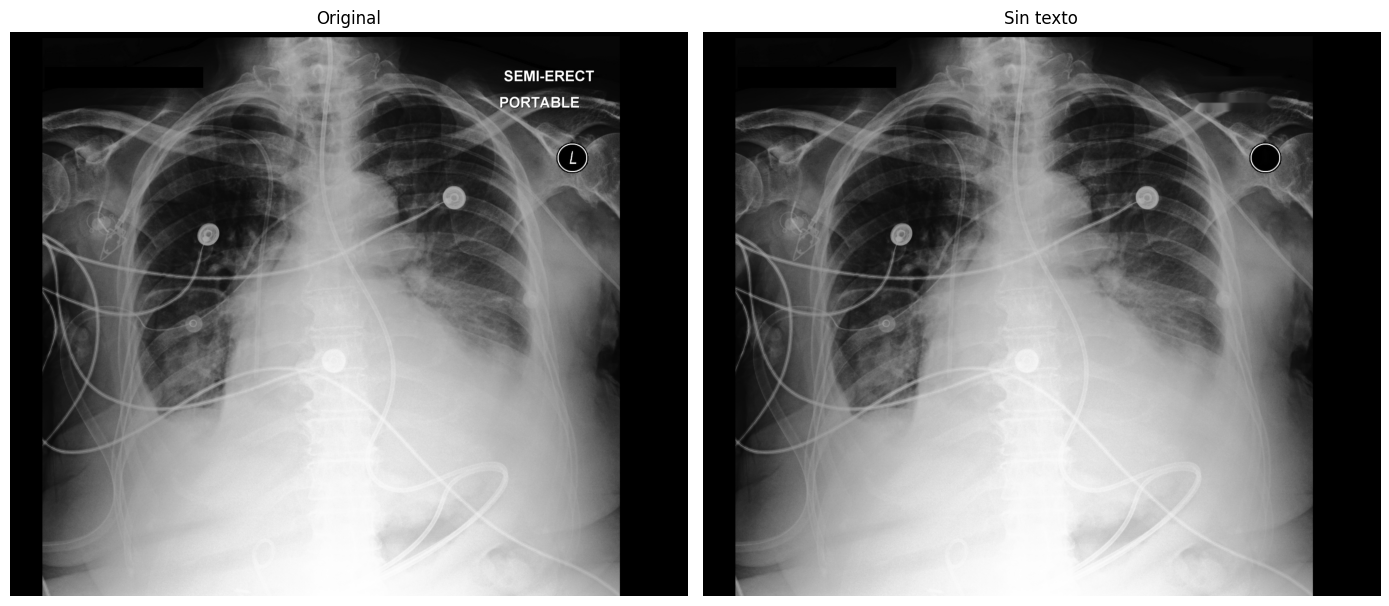

In [27]:

import matplotlib.pyplot as plt

image_path = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset_prueba\subset_pa_ap\s50805197\fc09630f-022d31c2-408b148f-95c499df-e8a6b18e.jpg'

# Imagen original
img_original = cv2.imread(image_path)
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Imagen sin texto
img_limpia = eliminar_texto(image_path)
img_limpia_rgb = cv2.cvtColor(img_limpia, cv2.COLOR_BGR2RGB)

# Mostrar antes / después
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_original_rgb, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_limpia_rgb, cmap='gray')
axes[1].set_title('Sin texto')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [2]:
def remove_laterality_circle(image: np.ndarray,
                              search_top_fraction: float = 0.20,
                              dp: float = 1.2,
                              min_dist: int = 30,
                              param1: int = 50,
                              param2: int = 45,
                              min_radius: int = 15,
                              max_radius: int = 40) -> np.ndarray:
    result = image.copy()
    h, w = image.shape[:2]
    search_h = int(h * search_top_fraction)
    roi = image[:search_h, :]

    if roi.dtype != np.uint8:
        roi_8 = cv2.normalize(roi, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        roi_8 = roi.copy()

    roi_gray = cv2.cvtColor(roi_8, cv2.COLOR_BGR2GRAY) if roi_8.ndim == 3 else roi_8
    roi_blurred = cv2.GaussianBlur(roi_gray, (5, 5), 1)

    circles = cv2.HoughCircles(
        roi_blurred, cv2.HOUGH_GRADIENT,
        dp=dp, minDist=min_dist,
        param1=param1, param2=param2,
        minRadius=min_radius, maxRadius=max_radius
    )

    if circles is not None:
        circles = np.round(circles[0, :]).astype(int)
        print(f"  Círculos detectados: {len(circles)}")

        for (cx, cy, r) in circles:
            mask = np.zeros((search_h, w), dtype=np.uint8)
            cv2.circle(mask, (cx, cy), r + 3, 255, -1)

            # Mismo inpaint suave que eliminar_texto
            roi_inpainted = cv2.inpaint(
                result[:search_h], mask,
                inpaintRadius=7, flags=cv2.INPAINT_TELEA
            )
            result[:search_h] = roi_inpainted
            print(f"    Círculo ({cx},{cy}) r={r} → inpaint TELEA")
    else:
        print("  No se detectaron círculos")

    return result

In [3]:
def limpiar_imagen(image_path):
    # Paso 1: EasyOCR para texto
    img = eliminar_texto(image_path)  # tu función actual
    
    # Paso 2: HoughCircles para marcador de lateralidad
    img = remove_laterality_circle(img)
    
    return img

  No se detectaron círculos


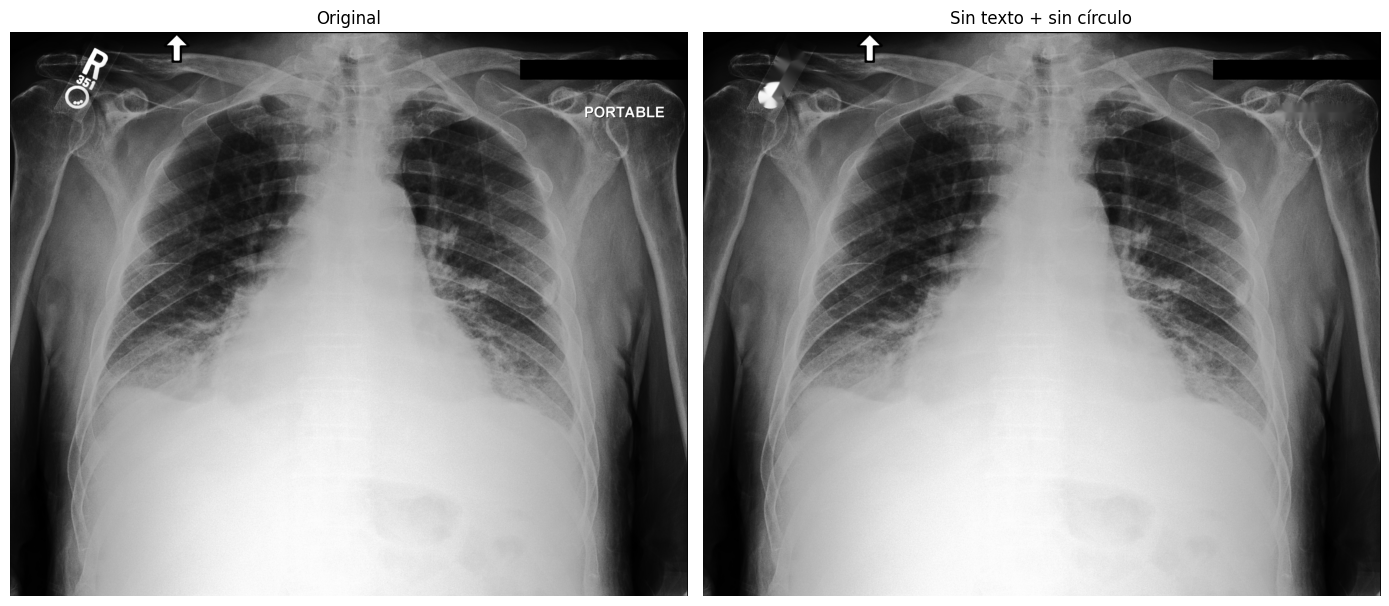

In [30]:
import matplotlib.pyplot as plt
import cv2
image_path = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset_prueba\subset_pa_ap\s50240426\513c95e3-f48c181d-c283dbc5-e02d8a5a-4b0048b9.jpg'
#image_path = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset_prueba\subset_pa_ap\s50805197\fc09630f-022d31c2-408b148f-95c499df-e8a6b18e.jpg'

# Imagen original
img_original = cv2.imread(image_path)
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Imagen sin texto Y sin círculo
img_limpia = eliminar_texto(image_path)           # EasyOCR → inpaint
img_limpia = remove_laterality_circle(img_limpia)  # HoughCircles → inpaint
img_limpia_rgb = cv2.cvtColor(img_limpia, cv2.COLOR_BGR2RGB)

# Mostrar antes / después
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_original_rgb, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_limpia_rgb, cmap='gray')
axes[1].set_title('Sin texto + sin círculo')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---------------------------------------------------------------------------
CODIGO PARA LIMPIAR IMAGEN Y GUARDARLA
---------------------------------------------------------------------------

In [1]:
import os
import pandas as pd

BASE_DIR = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge'
CSV_PATH = os.path.join(BASE_DIR, 'df_subset_500.csv')

df = pd.read_csv(CSV_PATH)

def construir_rel_path(row):
    p_prefix  = 'p' + str(row['subject_id'])[:2]
    p_subject = 'p' + str(row['subject_id'])
    s_study   = 's' + str(row['study_id'])
    filename  = str(row['dicom_id']) + '.jpg'
    return '/'.join(['files', p_prefix, p_subject, s_study, filename])

df['full_path'] = df.apply(construir_rel_path, axis=1)

IMG_ROOT = os.path.join(BASE_DIR, 'imagenes')
existentes = df['full_path'].apply(lambda p: os.path.exists(os.path.join(IMG_ROOT, p))).sum()
print('Paths actualizados:', len(df))
print('Imagenes encontradas en disco:', existentes)
print(df['full_path'].iloc[0])

df.to_csv(CSV_PATH, index=False)
print('CSV guardado.')


Paths actualizados: 530
Imagenes encontradas en disco: 529
files/p10/p10516278/s53994171/1621b732-f77b9463-87769d53-3175e5ed-1822d35f.jpg
CSV guardado.


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

BASE_DIR = r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge'
CSV_PATH = os.path.join(BASE_DIR, 'df_subset_500.csv')
IMG_ROOT = os.path.join(BASE_DIR, 'imagenes')

df = pd.read_csv(CSV_PATH)

errores = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Limpiando imágenes'):
    ruta_completa = os.path.join(IMG_ROOT, row['full_path'])

    if not os.path.exists(ruta_completa):
        errores.append({'path': row['full_path'], 'motivo': 'no encontrada'})
        continue

    try:
        img_limpia = limpiar_imagen(ruta_completa)
        cv2.imwrite(ruta_completa, img_limpia)
    except Exception as e:
        errores.append({'path': row['full_path'], 'motivo': str(e)})

print(f'\nListo. {len(df) - len(errores)}/{len(df)} imágenes procesadas.')
if errores:
    print(f'{len(errores)} errores:')
    for err in errores:
        print(f"  {err['path']} → {err['motivo']}")
